# roads accident prediction

1.fill missing values
2. encode categorical values
3. scalling values
4. other steps
5. train model
or 
all steps in pipeline -> use the same pipeline within a single line of code in production

In [5]:
import pandas as pd
df=pd.read_csv('./data/road_acc.csv')
pd.set_option('display.max_columns',None)
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Age_band_of_driver           12316 non-null  str  
 3   Sex_of_driver                12316 non-null  str  
 4   Educational_level            11575 non-null  str  
 5   Vehicle_driver_relation      11737 non-null  str  
 6   Driving_experience           11487 non-null  str  
 7   Type_of_vehicle              11366 non-null  str  
 8   Owner_of_vehicle             11834 non-null  str  
 9   Service_year_of_vehicle      8388 non-null   str  
 10  Defect_of_vehicle            7889 non-null   str  
 11  Area_accident_occured        12077 non-null  str  
 12  Lanes_or_Medians             11931 non-null  str  
 13  Road_allignment              12174 non-null  str  
 14  T

# Data preparation

In [6]:
df.shape

(12316, 32)

<Axes: xlabel='Accident_severity'>

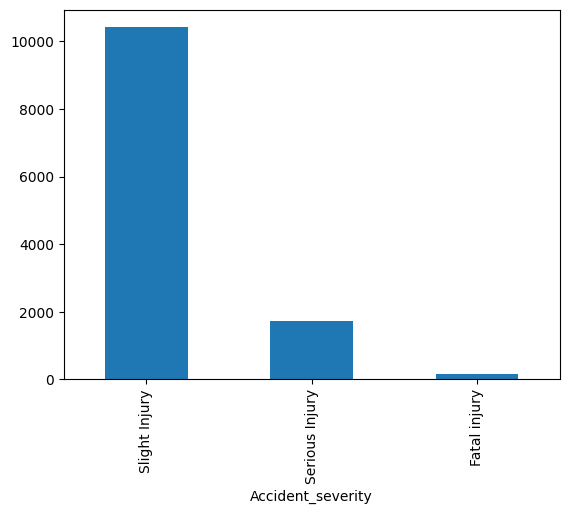

In [9]:
df['Accident_severity'].value_counts().plot(kind='bar')

<Axes: xlabel='Educational_level'>

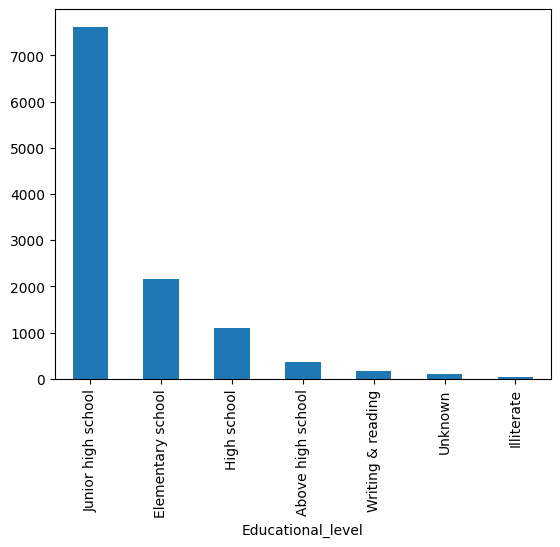

In [11]:
df['Educational_level'].value_counts().plot(kind='bar')

In [14]:
df['Time']=pd.to_datetime(df['Time'])
df['Hour_of_Day']=df['Time'].dt.hour
df['Time'].info()

<class 'pandas.Series'>
RangeIndex: 12316 entries, 0 to 12315
Series name: Time
Non-Null Count  Dtype         
--------------  -----         
12316 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 96.3 KB


In [15]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour_of_Day
0,2026-06-05 17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury,17
1,2026-06-05 17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury,17
2,2026-06-05 17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,2026-06-05 01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,2026-06-05 01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury,1


In [18]:
new_df=df.copy()
new_df.drop(['Time'],axis=1, inplace=True)

# Encode Target Column

In [20]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
new_df['Accident_severity']=le.fit_transform(new_df['Accident_severity'])

In [26]:
new_df['Accident_severity'].value_counts()

Accident_severity
2    10415
1     1743
0      158
Name: count, dtype: int64

# Balance Dataset
Kod Arka Planda Ne Yapıyor?
RandomOverSampler, kazaların şiddeti (Accident_severity) sütunundaki azınlıkta olan sınıfları (örneğin "Ağır Yaralanmalı" veya "Ölümlü" kaza sayıları az ise), çoğunlukta olan sınıfın sayısına eşitleyene kadar rastgele kopyalayarak (çoğaltarak) verinizi dengeler.

Buradaki işlem kesinlikle aynı veriyi kendi içinde kopyalayıp yapıştırmaktır (Copy-Paste). Sıfırdan yeni, yapay (sentetik) bir veri üretilmez.

Kullandığınız yöntemin adı zaten RandomOverSampler (Rastgele Aşırı Örnekleyici). Bu yöntem tam olarak şöyle çalışır:

Veri setinizdeki azınlıkta olan (sayısı az olan) sınıfın satırlarını bulur.

Bu satırlardan rastgele seçip tamamen aynı olacak şekilde kopyalar ve veri setine ekler.

Azınlık sınıfın sayısı, çoğunluk sınıfın sayısına eşitlenene kadar bu kopyalama işlemine devam eder.

In [29]:
from imblearn.over_sampling import RandomOverSampler

X=new_df.drop(columns=['Accident_severity'])
y=new_df['Accident_severity']

oversample=RandomOverSampler(random_state=42)

X_resampled, y_resampled = oversample.fit_resample(X,y)

In [31]:
y_resampled.value_counts()

Accident_severity
2    10415
1    10415
0    10415
Name: count, dtype: int64

# train/test/split

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Filling Missing Values

In [38]:
new_df.isnull().sum()

Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality              3198
Fitness_of_casuality        

# Encode Categorical Columns

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# define the stratagies for each column

strategies = {
    3: 'most_frequent',   # Educational_level
    4: 'most_frequent',   # Vehicle_driver_relation
    5: 'most_frequent',   # Driving_experience
    6: 'most_frequent',   # Type_of_vehicle
    8: 'constant',        # Service_year_of_vehicle
    9: 'constant',        # Defect_of_vehicle
    10: 'most_frequent',  # Area_accident_occured
    11: 'most_frequent',  # Lanes_or_Medians
    12: 'most_frequent',  # Road_allignment
    13: 'most_frequent',  # Types_of_Junction
    14: 'most_frequent',  # Road_surface_type
    18: 'most_frequent',  # Type_of_collision
    21: 'most_frequent',  # Vehicle_movement
    26: 'most_frequent',  # Work_of_casuality
    27: 'most_frequent'   # Fitness_of_casuality
}

# Create a ColumnTransformer for data preprocessing
tf1 = ColumnTransformer([
    ('impute_educational_level', SimpleImputer(strategy=strategies[3]), [3]),
    ('impute_Vehicle_driver_relation', SimpleImputer(strategy=strategies[4]), [4]),
    ('impute_Driving_experience', SimpleImputer(strategy=strategies[5]), [5]),
    ('impute_Type_of_vehicle', SimpleImputer(strategy=strategies[6]), [6]),
    ('impute_Service_year_of_vehicle', SimpleImputer(strategy=strategies[8], fill_value='Unknown'), [8]),
    ('impute_Defect_of_vehicle', SimpleImputer(strategy=strategies[9], fill_value='Unknown'), [9]),
    ('impute_Area_accident_occured', SimpleImputer(strategy=strategies[10]), [10]),
    ('impute_Lanes_or_Medians', SimpleImputer(strategy=strategies[11]), [11]),
    ('impute_Road_allignment', SimpleImputer(strategy=strategies[12]), [12]),
    ('impute_Types_of_Junction', SimpleImputer(strategy=strategies[13]), [13]),
    ('impute_Road_surface_type', SimpleImputer(strategy=strategies[14]), [14]),
    ('impute_Type_of_collision', SimpleImputer(strategy=strategies[18]), [18]),
    ('impute_Vehicle_movement', SimpleImputer(strategy=strategies[21]), [21]),
    ('impute_Work_of_casuality', SimpleImputer(strategy=strategies[26]), [26]),
    ('impute_Fitness_of_casuality', SimpleImputer(strategy=strategies[27]), [27])
], remainder='passthrough')

# Encode cat Columns

In [45]:
from sklearn.preprocessing import OneHotEncoder

# define the object column indices
object_columns_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,19,20,21,22,23,24,25,26,27,28,29,30]

# Create a ColumnTransformer for one hot encoding only objects coluöns

tf2= ColumnTransformer([
    (f'ohe_{col}',OneHotEncoder(sparse_output=False, handle_unknown='ignore'),[col])
    for col in object_columns_indices
],
remainder='passthrough'
)

# feature selection using the 'Chi2' Statistic
chi2: This is one of the scoring functions available for feature selection in scikit-learn. It calculates the chi-squared statistic between each feature and the target variable (accidents) to determine the relevance of each feature. chi2 is commonly used for feature selection when dealing with categorical target variables.


Bu kod satırı, veri setinizdeki onlarca veya yüzlerce özellik (sütun) arasından en anlamlı ve en güçlü 50 tanesini seçmeye yarar. Biz bu işleme makine öğrenmesinde Özellik Seçimi (Feature Selection) diyoruz.

1. chi2 (Ki-Kare Testi) Ne Yapıyor?
chi2 (Chi-Squared), istatistiksel bir testtir. Kategorik bağımsız değişkenleriniz ile hedef değişkeniniz (hedef sınıfınız) arasındaki ilişkiyi ölçer.

Her bir sütunun, hedef değişkeni tahmin etmede ne kadar etkili olduğuna dair bir puan (skor) hesaplar.

Hedef değişkenle hiçbir bağımsızlık ilişkisi olmayan, yani modele hiçbir faydası dokunmayacak "gereksiz" sütunlara düşük puan verir.

Neden Böyle Bir Şey Yapıyoruz? (Avantajları Nedir?)
Gereksiz Gürültüyü Azaltır: Veri setinizde modele hiçbir katkısı olmayan (örneğin hastanın ID numarası, test edildiği günün adı vb.) sütunlar varsa bunları eler.

Modeli Hızlandırır: Modeliniz yüzlerce sütunla uğraşmak yerine sadece en kaliteli 50 sütunla eğitileceği için çok daha hızlı çalışır.

Ezberlemeyi (Overfitting) Önler: Çok fazla gereksiz sütun, modelin verideki tesadüfi kalıpları ezberlemesine yol açabilir. Sütun sayısını optimize etmek modeli daha genel ve başarılı kılar.

In [47]:
from sklearn.feature_selection import SelectKBest, chi2
tf4=SelectKBest(chi2, k=50)


# Model (Random Forest Classifier)

In [48]:
from sklearn.ensemble import RandomForestClassifier

tf5=RandomForestClassifier()

# Create Pipeline

In [53]:
# construct the pipeline 
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('trf1',tf1),
    ('trf2',tf2), 
    ('trf4',tf4),
    ('trf5',tf5),
])
# Train the pipeline
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf1', ...), ('trf2', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_educational_level', ...), ('impute_Vehicle_driver_relation', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, d

# Explore the pipeline

In [57]:
pipe.classes_

array([0, 1, 2])

In [55]:
pipe.get_feature_names_out

<bound method Pipeline.get_feature_names_out of Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_educational_level',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [3]),
                                                 ('impute_Vehicle_driver_relation',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [4]),
                                                 ('impute_Driving_experience',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [5]),
                                                 ('impute_Type_of_vehicle',
                                                  SimpleImputer(stra...
                                     

# accuracy Score

In [58]:
# predict
from sklearn.metrics import accuracy_score
y_pred=pipe.predict(X_test)
accuracy_score(y_test, y_pred)

0.9243078892622819

# classification report

In [59]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [69]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[2085,    0,    0],
       [  22, 1995,   83],
       [  29,  339, 1696]])

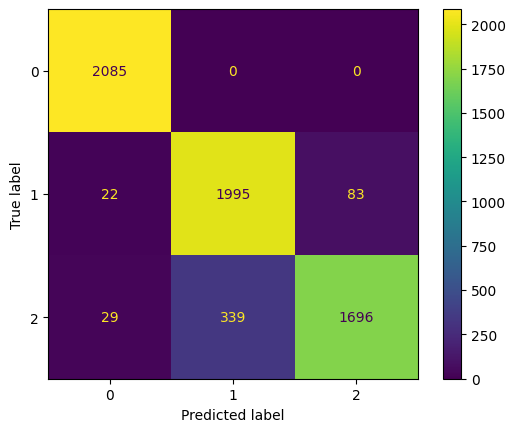

In [70]:
ConfusionMatrixDisplay(cm).plot()

In [60]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2085
           1       0.85      0.95      0.90      2100
           2       0.95      0.82      0.88      2064

    accuracy                           0.92      6249
   macro avg       0.93      0.92      0.92      6249
weighted avg       0.93      0.92      0.92      6249



# Save pipe

In [72]:
import pickle
pickle.dump(pipe,open('car_acc_pipe.pkl','wb'))

# Prediction system

In [82]:
import numpy as np
def pred(Day_of_week, Age_band_of_driver, Sex_of_driver, Educational_level, Vehicle_driver_relation,
         Driving_experience, Type_of_vehicle, Owner_of_vehicle, Service_year_of_vehicle,
         Defect_of_vehicle, Area_accident_occured, Lanes_or_Medians, Road_allignment,
         Types_of_Junction, Road_surface_type, Road_surface_conditions, Light_conditions,
         Weather_conditions, Type_of_collision, Number_of_vehicles_involved,
         Number_of_casualties, Vehicle_movement, Casualty_class, Sex_of_casualty,
         Age_band_of_casualty, Casualty_severity, Work_of_casuality, Fitness_of_casuality,
         Pedestrian_movement, Cause_of_accident, Hour_of_Day):
    
    # Your prediction code here
    features = np.array([[Day_of_week, Age_band_of_driver, Sex_of_driver, Educational_level, Vehicle_driver_relation,
         Driving_experience, Type_of_vehicle, Owner_of_vehicle, Service_year_of_vehicle,
         Defect_of_vehicle, Area_accident_occured, Lanes_or_Medians, Road_allignment,
         Types_of_Junction, Road_surface_type, Road_surface_conditions, Light_conditions,
         Weather_conditions, Type_of_collision, Number_of_vehicles_involved,
         Number_of_casualties, Vehicle_movement, Casualty_class, Sex_of_casualty,
         Age_band_of_casualty, Casualty_severity, Work_of_casuality, Fitness_of_casuality,
         Pedestrian_movement, Cause_of_accident, Hour_of_Day]])
    
    results = pipe.predict(features)
    return results

In [84]:
import warnings
warnings.filterwarnings('ignore') # Tüm uyarıları kapatır

In [85]:
predicted_class = pred(Day_of_week="Thursday", 
                                Age_band_of_driver='31-50',
                                Sex_of_driver='Male',
                                Educational_level='Junior high school',
                                Vehicle_driver_relation='Owner',
                                Driving_experience=None,
                                Type_of_vehicle='Long lorry',
                                Owner_of_vehicle='Owner',
                                Service_year_of_vehicle='Unknown',
                                Defect_of_vehicle=None,
                                Area_accident_occured='Other',
                                Lanes_or_Medians='Two-way (divided with solid lines road marking)',
                                Road_allignment='Tangent road with flat terrain',
                                Types_of_Junction=None,
                                Road_surface_type=None,
                                Road_surface_conditions='Dry',
                                Light_conditions='Daylight',
                                Weather_conditions='Normal',
                                Type_of_collision='Collision with animals',
                                Number_of_vehicles_involved=2,
                                Number_of_casualties=1,
                                Vehicle_movement='Going straight',
                                Casualty_class='Driver or rider',
                                Sex_of_casualty='Male',
                                Age_band_of_casualty='18-30',
                                Casualty_severity=3,
                                Work_of_casuality='Driver',
                                Fitness_of_casuality='Normal',
                                Pedestrian_movement='Not a Pedestrian',
                                Cause_of_accident='Changing lane to the left',
                                Hour_of_Day=12)

if predicted_class[0] == 2:
    print("Slight Injury.....")
elif predicted_class[0] == 1:
    print("Serious Injury")
else:
    print("Fatal Injury")

Serious Injury


In [86]:
# test 2
predicted_class = pred(Day_of_week="Friday", 
                       Age_band_of_driver='31-50',
                       Sex_of_driver='Male',
                       Educational_level='Elementary school',
                       Vehicle_driver_relation='Employee',
                       Driving_experience='1-2yr',
                       Type_of_vehicle='Lorry (41?100Q)',
                       Owner_of_vehicle='Owner',
                       Service_year_of_vehicle=None,
                       Defect_of_vehicle='No defect',
                       Area_accident_occured='Office areas',
                       Lanes_or_Medians='Two-way (divided with broken lines road marking)',
                       Road_allignment='Tangent road with flat terrain',
                       Types_of_Junction='Y Shape',
                       Road_surface_type='Asphalt roads',
                       Road_surface_conditions='Dry',
                       Light_conditions='Daylight',
                       Weather_conditions='Normal',
                       Type_of_collision='Vehicle with vehicle collision',
                       Number_of_vehicles_involved=2,
                       Number_of_casualties=2,
                       Vehicle_movement='Going straight',
                       Casualty_class='na',
                       Sex_of_casualty='na',
                       Age_band_of_casualty='na',
                       Casualty_severity='na',
                       Work_of_casuality='Driver',
                       Fitness_of_casuality='Normal',
                       Pedestrian_movement='Not a Pedestrian',
                       Cause_of_accident='Changing lane to the left',
                       Hour_of_Day=1)

if predicted_class[0] == 2:
    print("Slight Injury")
elif predicted_class[0] == 1:
    print("Serious Injury")
else:
    print("Fatal Injury")

Slight Injury
